In [1]:
from pathlib import Path
from typing import Any, Literal

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dask.distributed import Client

from rojak.core.constants import TWENTIES_CLIMATOLOGICAL_PARAMETER
from rojak.core.data import shift_longitude
from rojak.core.indexing import concat_new_dim
from rojak.orchestrator.configuration import (
    RelationshipBetweenTypes,
    TurbulenceDiagnostics,
)
from rojak.orchestrator.lite_controller import (
    load_distribution_parameters_from_file,
    open_diagnostic_zarr,
)
from rojak.plot.utilities import StandardColourMaps, get_a_default_cmap
from rojak.turbulence.analysis import RelationshipBetweenXAndTurbulence, TransformToEDR
from rojak.turbulence.metrics import conditional_odds_ratio

## Helper functions

In [2]:
def sel_for_season[T: (xr.Dataset, xr.DataArray)](
    target_data: T,
    season: Literal["DJF", "MAM", "JJA", "SON"],
    time_dim_name: str = "time",
) -> T:
    return target_data.isel(
        indexers={time_dim_name: (target_data[time_dim_name].dt.season == season)}
    )

In [ ]:
def sel_hemisphere[T: (xr.Dataset, xr.DataArray)](
    target_data: T,
    hemisphere: Literal["NH", "SH"],
    mid_lat_cut_off: float = 25,
) -> T:
    lat_slice = (
        slice(70, mid_lat_cut_off)
        if hemisphere == "NH"
        else slice(-mid_lat_cut_off, -70)
    )
    return target_data.sel(latitude=lat_slice)

In [ ]:
def sel_subtropics[T: (xr.Dataset, xr.DataArray)](
    target_data: T,
    hemisphere: Literal["NH", "SH"],
    above_subtropic: bool,
    mid_lat_cut_off: float = 25,
    subtropic_cut_off: float = 35,
) -> T:
    if above_subtropic:
        lat_slice = (
            slice(70, subtropic_cut_off)
            if hemisphere == "NH"
            else slice(-subtropic_cut_off, -70)
        )
    else:
        lat_slice = (
            slice(subtropic_cut_off, mid_lat_cut_off)
            if hemisphere == "NH"
            else slice(-mid_lat_cut_off, -subtropic_cut_off)
        )
    return target_data.sel(latitude=lat_slice)

In [5]:
def map_conditional_odds_on_turb(
    is_turb_da: xr.DataArray,
    effect_of: xr.DataArray,
    *control_var: xr.DataArray,
    sum_over: list[str] | None = None,
    use_log: bool = True,
    new_dim_name: str = "concat_dim",
    dim_values: list[Any] | None = None,
) -> xr.DataArray:
    if dim_values is None:
        target_length = (
            2 if (control_var_len := len(control_var)) == 1 else control_var_len
        )
        dim_values = np.arange(target_length).tolist()

    return concat_new_dim(
        conditional_odds_ratio(
            effect_of, is_turb_da, *control_var, sum_over=sum_over, use_log=use_log
        ),
        dim_name=new_dim_name,
        dim_values=dim_values,
    )

In [6]:
def load_single_level_data(target_path: Path, target_var: str) -> xr.DataArray:
    loaded_ds: xr.Dataset = xr.open_mfdataset(
        str(target_path / "*.nc"),
        chunks={"pressure_level": 6, "latitude": 721, "longitude": 1440},
        parallel=True,
        engine="h5netcdf",
        decode_coords=True,
        decode_cf=True,
        decode_timedelta=True,
    ).rename({"valid_time": "time"})
    return shift_longitude(loaded_ds[target_var])

In [7]:
def compute_vertical_velocity_masks(
    vertical_velocities: xr.DataArray, pressure_levels: xr.DataArray
) -> list[xr.DataArray]:
    all_thresholds = [-0.22, -0.03, 0.03, 0.22]
    masks = []
    for i in range(len(all_thresholds) + 1):
        if i == 0:
            # Velocities < minimum threshold
            condition = vertical_velocities < all_thresholds[0]
        elif i == len(all_thresholds):
            # Velocities >= maximum threshold
            condition = vertical_velocities >= all_thresholds[-1]
        else:
            # Velocities between two thresholds
            condition = (vertical_velocities >= all_thresholds[i - 1]) & (
                vertical_velocities < all_thresholds[i]
            )

        masks.append(
            condition.isel(pressure_level=0)
            .expand_dims(dim={"pressure_level": pressure_levels})
            .assign_coords({"pressure_level": pressure_levels})
        )
    return masks

In [8]:
def case_labels_vertical_velocity_thresholds(as_latex: bool = False) -> list[str]:
    all_thresholds = [-0.22, -0.03, 0.03, 0.22]
    labels = []
    leq = " \\leq " if as_latex else "<="
    geq = " \\geq " if as_latex else ">="

    for i in range(len(all_thresholds) + 1):
        if i == 0:
            # First bin: w < minimum
            labels.append(f"w<{all_thresholds[0]}")
        elif i == len(all_thresholds):
            # Last bin: w >= maximum
            labels.append(f"w{geq}{all_thresholds[-1]}")
        else:
            # Middle bins: threshold[i-1] <= w < threshold[i]
            lower = all_thresholds[i - 1]
            upper = all_thresholds[i]
            labels.append(f"{lower}{leq}w<{upper}")

    if as_latex:
        labels = [f"${item}$" for item in labels]

    return labels

## Constants

The `TARGET_SEASON` and `TARGET_HEMISPHERE` are changed to get the 4 permutations. This is done manually instead of a loop as memory is the limiting factor when running this locally.

In [9]:
TARGET_SEASON = "JJA"
TARGET_HEMISPHERE = "NH"
EDR_THRESHOLD: float = 0.22

In [10]:
client = Client()

## Recompute latitudinal marginal

As this is for the full study period (2023-2025), this is pre-computed for performance reasons. 

In [ ]:
# lat_mean_dims = ["time", "longitude"]

# base_path = Path("/path/to/exported-diagnostics/")
# target_diagnostics = [
#     # TurbulenceDiagnostics.NCSU1,
#     # TurbulenceDiagnostics.TI1,
#     TurbulenceDiagnostics.BROWN2,
# ]
# diagnostics = {
#     target_diagnostic: open_diagnostic_zarr(
#         base_path / f"{target_diagnostic}.zarr", target_diagnostic
#     )
#     for target_diagnostic in target_diagnostics
# }
# dist_params_file = Path(
#     "/path/to/distribution_params.json"
# )
# distribution_parameters = load_distribution_parameters_from_file(dist_params_file)

In [12]:
# is_turb = {
#     target_diagnostic: (
#         TransformToEDR(
#             diagnostics[target_diagnostic],
#             c1=TWENTIES_CLIMATOLOGICAL_PARAMETER.c1,
#             c2=TWENTIES_CLIMATOLOGICAL_PARAMETER.c2,
#             mean=distribution_parameters[str(target_diagnostic)].mean,
#             variance=distribution_parameters[str(target_diagnostic)].variance,
#         ).execute()
#         > EDR_THRESHOLD
#     ).persist()
#     for target_diagnostic in target_diagnostics
# }

In [ ]:
# issr_base_path = Path("/path/to/issr")
# iss_regions = xr.open_zarr(issr_base_path / "issr.zarr", chunks="auto")["issr"]

In [14]:
# marginal_case = RelationshipBetweenXAndTurbulence(
#     iss_regions,
#     xr.Dataset(data_vars=is_turb),
#     RelationshipBetweenTypes.SAMPLE_ODDS_RATIO,
#     sum_over_dim=lat_mean_dims,
# ).execute()


In [15]:
# by_pl = marginal_case.compute()

Note: This exports each of the marginal odds ratios individually (i.e., for each turbulence diagnostic). This notebook uses a zarr file with the marginal odds ratio of all three diagnostics. This has been achieved by copying the relevant folders into the combined zarr and updating the metadata accordingly.

In [ ]:
# marginal_case.to_zarr(
#     "/path/to/exported/marginal-odds-ratio.zarr", mode="w", zarr_format=2
# )

## Compute diff from marginal

### Load data

Import the required data and compute the necessary variables for computing  $\log \frac{\theta}{\theta_{\text{clim}}}$

In [ ]:
dist_params_file = Path("/path/to/distribution_params.json")
distribution_parameters = load_distribution_parameters_from_file(dist_params_file)

base_path = Path("/path/to/exported-diagnostics/")
target_diagnostics = [
    TurbulenceDiagnostics.TI1,
    TurbulenceDiagnostics.NCSU1,
    TurbulenceDiagnostics.BROWN2,
]
diagnostics = {
    target_diagnostic: sel_hemisphere(
        sel_for_season(
            open_diagnostic_zarr(
                base_path / f"{target_diagnostic}.zarr", target_diagnostic
            ),
            TARGET_SEASON,
        ),
        TARGET_HEMISPHERE,
    ).sel(pressure_level=slice(300, 200))
    for target_diagnostic in target_diagnostics
}
is_turb = {
    target_diagnostic: (
        TransformToEDR(
            diagnostics[target_diagnostic],
            c1=TWENTIES_CLIMATOLOGICAL_PARAMETER.c1,
            c2=TWENTIES_CLIMATOLOGICAL_PARAMETER.c2,
            mean=distribution_parameters[str(target_diagnostic)].mean,
            variance=distribution_parameters[str(target_diagnostic)].variance,
        ).execute()
        > EDR_THRESHOLD
    )
    for target_diagnostic in target_diagnostics
}

In [ ]:
issr_base_path = Path("/path/to/issr")
iss_regions = sel_hemisphere(
    sel_for_season(
        xr.open_zarr(issr_base_path / "issr.zarr", chunks="auto")["issr"], TARGET_SEASON
    ),
    TARGET_HEMISPHERE,
)

In [ ]:
w_path = Path(f"/path/to/era5_data/vertical-velocity/{TARGET_SEASON.lower()}-2023-2025")
vertical_velocity = load_single_level_data(w_path, "w")
vertical_velocity = sel_hemisphere(vertical_velocity, TARGET_HEMISPHERE).persist()

In [ ]:
marginal_case = sel_hemisphere(
    xr.open_zarr(
        "/path/to/exported/marginal-odds-ratio/marginal-odds-ratio-combined.zarr"
    ),
    TARGET_HEMISPHERE,
)

In [21]:
sum_over_dims = ["time", "longitude"]

### Compute  $\log \frac{\theta}{\theta_{\text{clim}}}$ 

In [ ]:
turb_as_ds = xr.Dataset(data_vars=is_turb)
dim_names = case_labels_vertical_velocity_thresholds()
vertical = compute_vertical_velocity_masks(
    vertical_velocity, is_turb[target_diagnostics[0]]["pressure_level"]
)
season_marginal_case = (
    RelationshipBetweenXAndTurbulence(
        iss_regions,
        turb_as_ds,
        RelationshipBetweenTypes.SAMPLE_ODDS_RATIO,
        sum_over_dim=sum_over_dims,
    )
    .execute()
    .assign_coords({"conditions": "marginal"})
)
conditional_odds_of_cases = turb_as_ds.map(
    map_conditional_odds_on_turb,
    keep_attrs=False,
    args=[iss_regions, *vertical],
    sum_over=sum_over_dims,
    use_log=True,
    new_dim_name="conditions",
    dim_values=dim_names,
)
all_odds_ratios = xr.concat(
    [conditional_odds_of_cases, season_marginal_case], dim="conditions"
)

difference = all_odds_ratios - marginal_case

### Plot $\log \frac{\theta}{\theta_{\text{clim}}}$

For a visual sanity check that it matches the results from the previously HPC computed plots and that mean looks correct.

In [24]:
COOL_WARM_CMAP = get_a_default_cmap(
    StandardColourMaps.CORRELATION_COOL_WARM, load_kwargs={"cmap_type": "continuous"}
).resampled(18)

In [ ]:
fg = difference.to_dataarray("diagnostics").plot(
    row="conditions",
    col="diagnostics",
    x="latitude",
    cbar_kwargs={
        "orientation": "horizontal",
        "spacing": "uniform",
        "shrink": 0.6,
        "label": "$\\vartheta$",
    },
    robust=True,
    center=0,
    rasterized=True,
    vmax=1,
    vmin=-1,
    cmap=COOL_WARM_CMAP,
    col_wrap=3,
    yincrease=False,
    aspect=1.4,
    size=2.2,
    xincrease=False,
)

### Table Stats

In [ ]:
mean_across_latitudes = difference.mean(
    dim=["latitude", "pressure_level"], skipna=True
).compute()

print(f"Season: {TARGET_SEASON}, Hemisphere: {TARGET_HEMISPHERE}")
print(f"Conditions: {difference['conditions'].values}")
print()
for key, value in mean_across_latitudes.items():
    print(f"{key}: {value.values}")

## Collate Results

Season: DJF, Hemisphere: SH

```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ncsu1:  [-0.51084982, -0.70508365, -0.59473435, -0.4579662 , -0.40452952, -0.45276677]
ti1:    [ 0.00385139, -0.30036412, -0.48119971, -0.52756072, -0.38468558, -0.27362372]
brown2: [-0.14902777, -0.4541128 , -0.61561302, -0.63495814, -0.61925523, -0.42241699]
```

Season: DJF, Hemisphere: NH

```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ncsu1:  [0.27021039, -0.06877204, -0.01166077, 0.03319941, -0.07343943, 0.19841459]
ti1:    [0.45443734, 0.1955794,    0.21889209, 0.23154495, 0.27781788 ,0.31836181]
brown2: [0.4429578 , 0.2632938,    0.31655578, 0.34243203, 0.33037005 ,0.37121305]
```

Season: JJA, Hemisphere: NH

```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ncsu1:  [-0.18428619, -0.58820845, -0.59182034, -0.53299172, -0.3075436 , -0.35481699]
ti1:    [-0.13407615, -0.38082884, -0.50447691, -0.57053141, -0.36159162, -0.39669808]
brown2: [-0.5074484 , -0.59000263, -0.62963805, -0.74479957, -0.74553446, -0.6570702 ]
```

Season: JJA, Hemisphere: SH
```python
Conditions: ['w<-0.22' '-0.22<=w<-0.03' '-0.03<=w<0.03' '0.03<=w<0.22' 'w>=0.22'
 'marginal']

ncsu1:  [0.25513663, -0.02292296,0.11296884, 0.36646041, 0.63311293, 0.33202582]
ti1:    [0.5844758 , 0.20079177 ,0.15391166, 0.23003821, 0.44146147, 0.35394537]
brown2: [0.62719986, 0.28915081 ,0.2291673 , 0.32024705, 0.48197001, 0.42658535]
```

In [ ]:
conditions = [
    "w<-0.22",
    "-0.22<=w<-0.03",
    "-0.03<=w<0.03",
    "0.03<=w<0.22",
    "w>=0.22",
    "marginal",
]
criteria = ["ti1", "ncsu1", "brown2"]
seasons = ["DJF", "JJA"]
hemispheres = ["NH", "SH"]

data_diff = {
    ("DJF", "NH"): {
        "ncsu1": [
            0.27021039,
            -0.06877204,
            -0.01166077,
            0.03319941,
            -0.07343943,
            0.19841459,
        ],
        "ti1": [0.45443734, 0.1955794, 0.21889209, 0.23154495, 0.27781788, 0.31836181],
        "brown2": [
            0.4429578,
            0.2632938,
            0.31655578,
            0.34243203,
            0.33037005,
            0.37121305,
        ],
    },
    ("DJF", "SH"): {
        "ncsu1": [
            -0.51084982,
            -0.70508365,
            -0.59473435,
            -0.4579662,
            -0.40452952,
            -0.45276677,
        ],
        "ti1": [
            0.00385139,
            -0.30036412,
            -0.48119971,
            -0.52756072,
            -0.38468558,
            -0.27362372,
        ],
        "brown2": [
            -0.14902777,
            -0.4541128,
            -0.61561302,
            -0.63495814,
            -0.61925523,
            -0.42241699,
        ],
    },
    ("JJA", "NH"): {
        "ncsu1": [
            -0.18428619,
            -0.58820845,
            -0.59182034,
            -0.53299172,
            -0.3075436,
            -0.35481699,
        ],
        "ti1": [
            -0.13407615,
            -0.38082884,
            -0.50447691,
            -0.57053141,
            -0.36159162,
            -0.39669808,
        ],
        "brown2": [
            -0.5074484,
            -0.59000263,
            -0.62963805,
            -0.74479957,
            -0.74553446,
            -0.6570702,
        ],
    },
    ("JJA", "SH"): {
        "ncsu1": [
            0.25513663,
            -0.02292296,
            0.11296884,
            0.36646041,
            0.63311293,
            0.33202582,
        ],
        "ti1": [0.5844758, 0.20079177, 0.15391166, 0.23003821, 0.44146147, 0.35394537],
        "brown2": [
            0.62719986,
            0.28915081,
            0.2291673,
            0.32024705,
            0.48197001,
            0.42658535,
        ],
    },
}

da_diff = xr.DataArray(
    data=np.array(
        [
            [
                [data_diff[(season, hemi)][crit] for crit in criteria]
                for hemi in hemispheres
            ]
            for season in seasons
        ]
    ),
    dims=["season", "hemisphere", "diagnostic", "condition"],
    coords={
        "season": seasons,
        "hemisphere": hemispheres,
        "diagnostic": criteria,
        "condition": conditions,
    },
    name="theta",
)

conditions = conditions[::-1]

In [12]:
def get_panel_letter(panel_index: int, is_lower: bool = True) -> str:
    start_char = "`" if is_lower else "@"
    return chr(ord(start_char) + panel_index + 1)

Note: Plotting for this was initially generated by Claude Sonnet 4.6 and has been adapted accordingly to improve the clarity

In [ ]:
condition_labels = {
    "w<-0.22": r"$w < -0.22$",
    "-0.22<=w<-0.03": r"$-0.22 \leq w < -0.03$",
    "-0.03<=w<0.03": r"$-0.03 \leq w < 0.03$",
    "0.03<=w<0.22": r"$0.03 \leq w < 0.22$",
    "w>=0.22": r"$w \geq 0.22$",
    "marginal": "marginal",  # plain text as requested
}

season_hemi_to_period = {
    ("DJF", "NH"): "winter",
    ("DJF", "SH"): "summer",
    ("JJA", "NH"): "summer",
    ("JJA", "SH"): "winter",
}

HEMI_MARKERS = {
    "NH": "x",
    "SH": "o",
}

MARKER_SIZE = 9
MARKER_LW = 2  # line width for "x" markers
CRITERIA_LABELS = {"ti1": "Turbulence Index 1", "brown2": "Brown2", "ncsu1": "NCSU1"}

n_criteria = len(criteria)

PERIOD_MARKERS = {
    "summer": "x",
    "winter": "o",
}
SEASON_COLOURS = {
    "DJF": "#7B2D8B",  # purple
    "JJA": "#009E73",  # green
}

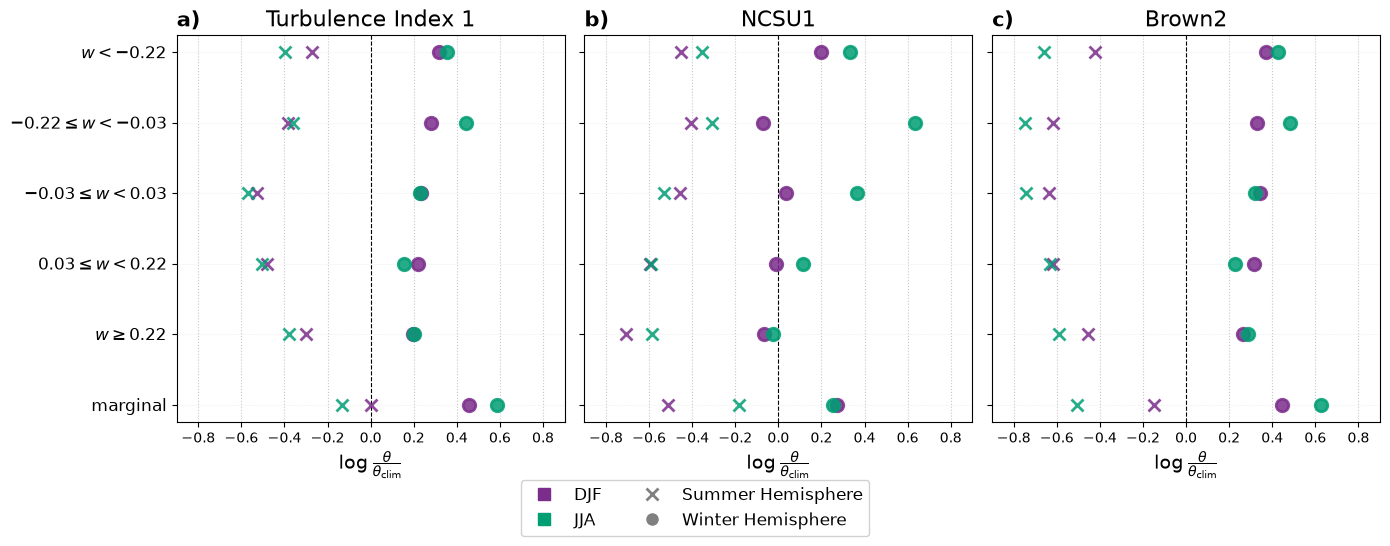

In [ ]:
all_values = da_diff.values.ravel()
x_min = np.floor(all_values.min() * 10) / 10 - 0.1
x_max = np.ceil(all_values.max() * 10) / 10 + 0.1

x_lims = np.abs(x_min) if np.abs(x_min) > np.abs(x_max) else np.abs(x_max)
x_min = -x_lims
x_max = x_lims

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_criteria,
    figsize=(14, 5),
    sharey=True,
    sharex=True,
    layout="tight",
)

y_positions = np.arange(len(conditions))

combinations = [
    ("DJF", "NH"),
    ("DJF", "SH"),
    ("JJA", "NH"),
    ("JJA", "SH"),
]

for ci, (crit, ax) in enumerate(zip(criteria, axes)):
    for season, hemi in combinations:
        period = season_hemi_to_period[(season, hemi)]
        values = da_diff.sel(season=season, hemisphere=hemi, diagnostic=crit).values

        ax.plot(
            values,
            y_positions,
            linestyle="none",
            marker=PERIOD_MARKERS[period],
            color=SEASON_COLOURS[season],
            markersize=MARKER_SIZE,
            markeredgewidth=MARKER_LW,
            alpha=0.85,
            zorder=3,
        )

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", zorder=2)
    ax.set_title(CRITERIA_LABELS[crit], fontsize=16)
    ax.set_title(f"{get_panel_letter(ci)})", loc="left", fontweight="bold", fontsize=15)
    ax.set_xlabel(r"$\log\frac{\theta}{\theta_{\text{clim}}}$", fontsize=14)
    ax.set_xlim(x_min, x_max)
    ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.grid(axis="y", linestyle=":", linewidth=0.4, alpha=0.4)
    ax.set_axisbelow(True)

    if ci == 0:
        ax.set_yticks(y_positions)
        ax.set_yticklabels(
            [condition_labels[c] for c in conditions],
            fontsize=12,
        )
    else:
        ax.set_yticks(y_positions)

legend_elements = [
    mlines.Line2D(
        [],
        [],
        color=SEASON_COLOURS["DJF"],
        marker="s",
        linestyle="none",
        markersize=8,
        label="DJF",
    ),
    mlines.Line2D(
        [],
        [],
        color=SEASON_COLOURS["JJA"],
        marker="s",
        linestyle="none",
        markersize=8,
        label="JJA",
    ),
    mlines.Line2D(
        [],
        [],
        color="grey",
        marker="x",
        linestyle="none",
        markersize=8,
        markeredgewidth=2,
        label="Summer Hemisphere",
    ),
    mlines.Line2D(
        [],
        [],
        color="grey",
        marker="o",
        linestyle="none",
        markersize=8,
        label="Winter Hemisphere",
    ),
]

legend = fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    fontsize=12,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.10),
)

plt.savefig("diff_theta.png", bbox_inches="tight", transparent=True)
plt.show()